In [1]:

import time                                   
import numpy as np                            
import pandas as pd                           
import matplotlib.pyplot as plt               

from sklearn.model_selection import train_test_split   
from sklearn.preprocessing import StandardScaler       
from sklearn.metrics import classification_report      

In [2]:
DATA_PATH = 'Cars.csv'
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)

Raw shape: (8128, 13)


In [3]:
df = df.drop_duplicates()

df = df[~df['fuel'].isin(['CNG', 'LPG'])]

owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}
df['owner'] = df['owner'].map(owner_map)

df = df[df['owner'] != 5]

df = df.drop(columns=['torque'])
print("Shape after row/column removal:", df.shape)

Shape after row/column removal: (6827, 12)


In [4]:
df['mileage'] = df['mileage'].str.split().str[0]
df['mileage'] = df['mileage'].astype(float)

df['engine'] = df['engine'].str.split().str[0]
df['engine'] = df['engine'].astype(float)

df['max_power'] = df['max_power'].str.split().str[0]
df['max_power'] = df['max_power'].astype(float)

df['name'] = df['name'].str.split().str[0]

print("Shape after cleaning:", df.shape)
print("Missing values per column:")
print(df.isna().sum())

Shape after cleaning: (6827, 12)
Missing values per column:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
dtype: int64


In [5]:
X = df.drop(columns=['selling_price'])

y_price = df['selling_price']

X_train, X_test, y_price_train, y_price_test = train_test_split(
    X, y_price, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)

X_train: (5461, 11) | X_test: (1366, 11)


In [6]:
num_features = ['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
cat_features = ['name', 'fuel', 'seller_type', 'transmission']

mileage_median   = X_train['mileage'].median()
engine_median    = X_train['engine'].median()
max_power_median = X_train['max_power'].median()
seats_median     = X_train['seats'].median()

X_train['mileage'] = X_train['mileage'].fillna(mileage_median)
X_test['mileage']  = X_test['mileage'].fillna(mileage_median)

X_train['engine'] = X_train['engine'].fillna(engine_median)
X_test['engine']  = X_test['engine'].fillna(engine_median)

X_train['max_power'] = X_train['max_power'].fillna(max_power_median)
X_test['max_power']  = X_test['max_power'].fillna(max_power_median)

X_train['seats'] = X_train['seats'].fillna(seats_median)
X_test['seats']  = X_test['seats'].fillna(seats_median)

print("Missing values left (train, test):", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

Missing values left (train, test): 0 0


In [7]:
X_train = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cat_features, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

bool_cols = X_train.select_dtypes(include=bool).columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print("Final feature matrix shapes:", X_train.shape, X_test.shape)

Final feature matrix shapes: (5461, 41) (1366, 41)


In [8]:
raw_train = df.loc[X_train.index]                      
preprocess_info = {
    "columns": list(X_train.columns),                  
    "medians": {c: float(raw_train[c].median()) for c in num_features},   
    "modes":   {c: str(raw_train[c].mode()[0]) for c in cat_features},    
    "scaler_mean":  scaler.mean_.tolist(),             
    "scaler_scale": scaler.scale_.tolist(),            
}
print("Saved preprocessing info for", len(preprocess_info["columns"]), "feature columns")

Saved preprocessing info for 41 feature columns


In [9]:
# Learn the 3 cut-points (25%, 50%, 75% quantiles) from the TRAINING prices only
_, bin_edges = pd.qcut(y_price_train, q=4, retbins=True)   # bin_edges has 5 numbers: min, q25, q50, q75, max

# Replace the outer edges by -inf / +inf so any unseen test price still falls in class 0 or 3
bin_edges[0]  = -np.inf
bin_edges[-1] =  np.inf
print("Price cut-points between classes:", bin_edges[1:-1])

y_train = pd.cut(y_price_train, bins=bin_edges, labels=False).to_numpy().astype(int)
y_test  = pd.cut(y_price_test,  bins=bin_edges, labels=False).to_numpy().astype(int)

print("Train class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))

Price cut-points between classes: [250000. 415000. 650000.]
Train class counts: [1480 1266 1450 1265]
Test  class counts: [366 345 375 280]


In [10]:
X_train = X_train.to_numpy(dtype=float)
X_test  = X_test.to_numpy(dtype=float)

intercept = np.ones((X_train.shape[0], 1))
X_train   = np.concatenate((intercept, X_train), axis=1)
intercept = np.ones((X_test.shape[0], 1))
X_test    = np.concatenate((intercept, X_test), axis=1)

k = len(np.unique(y_train))
m = X_train.shape[0]
n = X_train.shape[1]

Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_train == each_class
    Y_train_encoded[np.where(cond), each_class] = 1

print(f"X_train {X_train.shape} | Y_train_encoded {Y_train_encoded.shape} | X_test {X_test.shape} | k={k}, m={m}, n={n}")

X_train (5461, 42) | Y_train_encoded (5461, 4) | X_test (1366, 42) | k=4, m=5461, n=42


In [11]:
class LogisticRegression:
    # CONSTRUCTOR
    def __init__(self, k, n, method, alpha=0.1, max_iter=5000, verbose=True):
        self.k = k                      
        self.n = n                      
        self.alpha = alpha              
        self.max_iter = max_iter        
        self.method = method            
        self.verbose = verbose          

    # TRAINING LOOP  [START]
    def fit(self, X, Y):
        self.W = np.random.rand(self.n, self.k)
        self.losses = []                

        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad = self.gradient(X, Y)            
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad         
                if self.verbose and i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            if self.verbose:
                print(f"time taken: {time.time() - start_time}")

        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])              # each mini-batch = 30% of the data
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0])       # random starting row (with replacement)
                batch_X = X[ix:ix + batch_size]
                batch_Y = Y[ix:ix + batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if self.verbose and i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            if self.verbose:
                print(f"time taken: {time.time() - start_time}")

        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = []
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while i in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx].reshape(1, -1)             # reshape to (1, k) so shapes are explicit
                loss, grad = self.gradient(X_train, Y_train)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad

                list_of_used_ix.append(i)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = []
                if self.verbose and i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            if self.verbose:
                print(f"time taken: {time.time() - start_time}")

        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')

    # LOSS + GRADIENT
    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)                          # predicted probabilities, (m, k)

        # [START] cross-entropy loss averaged over samples.  np.clip stops log(0)
        loss = - np.sum(Y * np.log(np.clip(h, 1e-15, 1))) / m

        error = h - Y                                        # (m, k)
        grad = self.softmax_grad(X, error) / m               # X^T (H - Y).  [MODIFIED] divided by m
        return loss, grad

    # SOFTMAX / PREDICT  [START]
    def softmax(self, theta_t_x):
        z = theta_t_x - np.max(theta_t_x, axis=1, keepdims=True)
        return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return X.T @ error                                   # (n, m) @ (m, k) = (n, k)

    def h_theta(self, X, W):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W)

    def predict(self, X_test):
        # pick the class with the highest probability in every row
        return np.argmax(self.h_theta(X_test, self.W), axis=1)

    def predict_proba(self, X_test):
        return self.h_theta(X_test, self.W)

    def plot(self):
        plt.plot(np.arange(len(self.losses)), self.losses, label="Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

In [12]:
def add_method(cls):
    def decorator(func):
        setattr(cls, func.__name__, func)   
        return func
    return decorator

In [13]:
# [START] Sanity check: train the class exactly as it is (no metrics added yet, no penalty)
np.random.seed(42)                                   # fixed seed -> the random starting weights are reproducible
model_plain = LogisticRegression(k=k, n=n, method="batch", alpha=0.1, max_iter=5000)
model_plain.fit(X_train, Y_train_encoded)

# plain numpy accuracy (the proper accuracy() method is added in Task 1 - Bullet 2)
quick_pred = model_plain.predict(X_test)
print("Quick check - share of test cars classified correctly:", np.mean(quick_pred == y_test))

Loss at iteration 0 1.6153260879539928
Loss at iteration 500 0.7109308364963642
Loss at iteration 1000 0.6633783688301143
Loss at iteration 1500 0.6413770574797877
Loss at iteration 2000 0.6281563843764406
Loss at iteration 2500 0.6192205740819745
Loss at iteration 3000 0.6127591728111867
Loss at iteration 3500 0.6078763158150696
Loss at iteration 4000 0.6040690090662507
Loss at iteration 4500 0.6010296654358168
time taken: 3.675295829772949
Quick check - share of test cars classified correctly: 0.7349926793557833


In [14]:
# accuracy = correct predictions / all predictions (a single number)
@add_method(LogisticRegression)
def accuracy(self, y_true, y_pred):
    y_true = np.asarray(y_true)                      
    y_pred = np.asarray(y_pred)
    return np.sum(y_true == y_pred) / len(y_true)    

In [15]:
# [T1-B2 TEST] A tiny hand-checkable example that I will keep re-using in Bullets 3, 4 and 5:
y_true_demo = np.array([0, 0, 1, 1, 1, 2, 3, 3])     # 8 cars: the truth
y_pred_demo = np.array([0, 1, 1, 1, 2, 2, 3, 0])     # the model's guesses (5 of 8 are right)

# I only need the metric methods here (no training), so create a model object with k = 4 classes
demo_model = LogisticRegression(k=4, n=1, method="batch")

acc = demo_model.accuracy(y_true_demo, y_pred_demo)
print("accuracy =", acc, "   (by hand: 5/8 =", 5/8, ")")
assert acc == 5/8

accuracy = 0.625    (by hand: 5/8 = 0.625 )


In [16]:
@add_method(LogisticRegression)
def _safe_divide(self, numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    out = np.zeros_like(numerator)
    np.divide(numerator, denominator, out=out, where=denominator != 0)
    return out

# helper: TP, FP, FN for every class at once
@add_method(LogisticRegression)
def _tp_fp_fn(self, y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.zeros(self.k)
    fp = np.zeros(self.k)
    fn = np.zeros(self.k)
    for c in range(self.k):
        tp[c] = np.sum((y_true == c) & (y_pred == c))    
        fp[c] = np.sum((y_true != c) & (y_pred == c))    
        fn[c] = np.sum((y_true == c) & (y_pred != c))    
    return tp, fp, fn

# precision_c = TP_c / (TP_c + FP_c)   (array with one value per class)
@add_method(LogisticRegression)
def precision(self, y_true, y_pred):
    tp, fp, fn = self._tp_fp_fn(y_true, y_pred)
    return self._safe_divide(tp, tp + fp)

# recall_c = TP_c / (TP_c + FN_c)   (array with one value per class)
@add_method(LogisticRegression)
def recall(self, y_true, y_pred):
    tp, fp, fn = self._tp_fp_fn(y_true, y_pred)
    return self._safe_divide(tp, tp + fn)

# f1_c = 2 * precision_c * recall_c / (precision_c + recall_c)   (one value per class)
@add_method(LogisticRegression)
def f1_score(self, y_true, y_pred):
    p = self.precision(y_true, y_pred)
    r = self.recall(y_true, y_pred)
    return self._safe_divide(2 * p * r, p + r)

In [17]:
# MACRO averages: plain average over the classes (every class counts equally)
@add_method(LogisticRegression)
def macro_precision(self, y_true, y_pred):
    return np.mean(self.precision(y_true, y_pred))

@add_method(LogisticRegression)
def macro_recall(self, y_true, y_pred):
    return np.mean(self.recall(y_true, y_pred))

@add_method(LogisticRegression)
def macro_f1(self, y_true, y_pred):
    return np.mean(self.f1_score(y_true, y_pred))

In [18]:
# support_c = how many samples truly belong to class c  (needed for the weights; see also Bullet 7)
@add_method(LogisticRegression)
def support(self, y_true):
    y_true = np.asarray(y_true)
    return np.array([np.sum(y_true == c) for c in range(self.k)])

# WEIGHTED averages: each class is weighted by its share of the data (support_c / total)
@add_method(LogisticRegression)
def weighted_precision(self, y_true, y_pred):
    weights = self.support(y_true) / len(y_true)
    return np.sum(weights * self.precision(y_true, y_pred))

@add_method(LogisticRegression)
def weighted_recall(self, y_true, y_pred):
    weights = self.support(y_true) / len(y_true)
    return np.sum(weights * self.recall(y_true, y_pred))

@add_method(LogisticRegression)
def weighted_f1(self, y_true, y_pred):
    weights = self.support(y_true) / len(y_true)
    return np.sum(weights * self.f1_score(y_true, y_pred))

In [19]:
# print a table that looks like scikit-learn's classification_report, built ONLY from my own functions
@add_method(LogisticRegression)
def classification_report_scratch(self, y_true, y_pred):
    p, r, f = self.precision(y_true, y_pred), self.recall(y_true, y_pred), self.f1_score(y_true, y_pred)
    s = self.support(y_true)
    total = len(y_true)
    lines = [f"{'':>14}{'precision':>10}{'recall':>10}{'f1-score':>10}{'support':>10}", ""]
    for c in range(self.k):
        lines.append(f"{c:>14}{p[c]:>10.2f}{r[c]:>10.2f}{f[c]:>10.2f}{s[c]:>10}")
    lines.append("")
    lines.append(f"{'accuracy':>14}{'':>10}{'':>10}{self.accuracy(y_true, y_pred):>10.2f}{total:>10}")
    lines.append(f"{'macro avg':>14}{self.macro_precision(y_true, y_pred):>10.2f}{self.macro_recall(y_true, y_pred):>10.2f}{self.macro_f1(y_true, y_pred):>10.2f}{total:>10}")
    lines.append(f"{'weighted avg':>14}{self.weighted_precision(y_true, y_pred):>10.2f}{self.weighted_recall(y_true, y_pred):>10.2f}{self.weighted_f1(y_true, y_pred):>10.2f}{total:>10}")
    print("\n".join(lines))

In [20]:
# Mock data: 300 fake samples, 4 classes with probabilities 20% / 30% / 20% / 30%
rng = np.random.default_rng(0)
y_true_mock = rng.choice(4, size=300, p=[0.2, 0.3, 0.2, 0.3])

# Fake predictions: 70% of the time correct, otherwise a random class
y_pred_mock = np.where(rng.random(300) < 0.7, y_true_mock, rng.integers(0, 4, size=300))

# Use the model object from Bullet 2 (k = 4 classes) just for its metric methods
metric_model = demo_model

print("=========== MY implementation (from scratch) ===========")
metric_model.classification_report_scratch(y_true_mock, y_pred_mock)

print("\n=========== scikit-learn classification_report ===========")
print(classification_report(y_true_mock, y_pred_mock))

=========== MY implementation (from scratch) ===========
               precision    recall  f1-score   support

             0      0.74      0.83      0.78        58
             1      0.82      0.77      0.79        77
             2      0.74      0.79      0.76        53
             3      0.88      0.83      0.85       112

      accuracy                          0.81       300
     macro avg      0.79      0.80      0.80       300
  weighted avg      0.81      0.81      0.81       300

=========== scikit-learn classification_report ===========
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        58
           1       0.82      0.77      0.79        77
           2       0.74      0.79      0.76        53
           3       0.88      0.83      0.85       112

    accuracy                           0.81       300
   macro avg       0.79      0.80      0.80       300
weighted avg       0.81      0.81      0.81       300



In [21]:
sk = classification_report(y_true_mock, y_pred_mock, output_dict=True)   
rows = []
for c in range(4):
    rows.append([f"class {c}",
                 metric_model.precision(y_true_mock, y_pred_mock)[c], sk[str(c)]['precision'],
                 metric_model.recall(y_true_mock, y_pred_mock)[c],    sk[str(c)]['recall'],
                 metric_model.f1_score(y_true_mock, y_pred_mock)[c],  sk[str(c)]['f1-score']])
rows.append(["accuracy", np.nan, np.nan, np.nan, np.nan,
             metric_model.accuracy(y_true_mock, y_pred_mock), sk['accuracy']])
rows.append(["macro avg",
             metric_model.macro_precision(y_true_mock, y_pred_mock), sk['macro avg']['precision'],
             metric_model.macro_recall(y_true_mock, y_pred_mock),    sk['macro avg']['recall'],
             metric_model.macro_f1(y_true_mock, y_pred_mock),        sk['macro avg']['f1-score']])
rows.append(["weighted avg",
             metric_model.weighted_precision(y_true_mock, y_pred_mock), sk['weighted avg']['precision'],
             metric_model.weighted_recall(y_true_mock, y_pred_mock),    sk['weighted avg']['recall'],
             metric_model.weighted_f1(y_true_mock, y_pred_mock),        sk['weighted avg']['f1-score']])

comparison = pd.DataFrame(rows, columns=["", "precision (mine)", "precision (sklearn)",
                                          "recall (mine)", "recall (sklearn)",
                                          "f1 (mine)", "f1 (sklearn)"]).set_index("")
display(comparison.round(4))

# [T1-B6] Confirm every number is (almost) identical -> raises an error if not
pairs = [("precision (mine)", "precision (sklearn)"), ("recall (mine)", "recall (sklearn)"), ("f1 (mine)", "f1 (sklearn)")]
for mine_col, sk_col in pairs:
    assert np.allclose(comparison[mine_col].dropna(), comparison[sk_col].dropna()), f"{mine_col} differs from sklearn!"
print("All metrics match scikit-learn (np.allclose = True).")

,precision (mine),precision (sklearn),recall (mine),recall (sklearn),f1 (mine),f1 (sklearn)
,,,,,,
class 0,0.7385,0.7385,0.8276,0.8276,0.7805,0.7805
class 1,0.8194,0.8194,0.7662,0.7662,0.7919,0.7919
class 2,0.7368,0.7368,0.7925,0.7925,0.7636,0.7636
class 3,0.8774,0.8774,0.8304,0.8304,0.8532,0.8532
accuracy,NaN,NaN,NaN,NaN,0.8067,0.8067
macro avg,0.7930,0.7930,0.8042,0.8042,0.7973,0.7973
weighted avg,0.8108,0.8108,0.8067,0.8067,0.8076,0.8076


All metrics match scikit-learn (np.allclose = True).


=========== MY classification report (real test set) ===========
               precision    recall  f1-score   support

             0      0.85      0.87      0.86       366
             1      0.65      0.61      0.62       345
             2      0.65      0.66      0.66       375
             3      0.80      0.83      0.81       280

      accuracy                          0.73      1366
     macro avg      0.74      0.74      0.74      1366
  weighted avg      0.73      0.73      0.73      1366

=========== scikit-learn classification report (real test set) ===========
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       366
           1       0.65      0.61      0.62       345
           2       0.65      0.66      0.66       375
           3       0.80      0.83      0.81       280

    accuracy                           0.73      1366
   macro avg       0.74      0.74      0.74      1366
weighted avg       0.73      0.73    

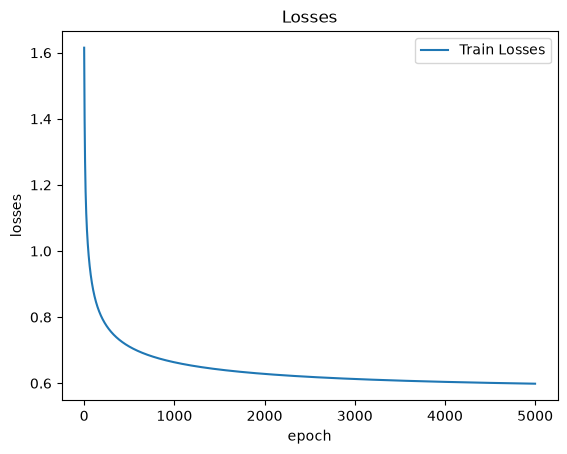

In [22]:
# Same comparison on the REAL model: the plain model trained in the STARTING POINT section
yhat_test = model_plain.predict(X_test)              

print("=========== MY classification report (real test set) ===========")
model_plain.classification_report_scratch(y_test, yhat_test)

print("\n=========== scikit-learn classification report (real test set) ===========")
print(classification_report(y_test, yhat_test))

model_plain.plot()                                   
plt.show()

Support is the number of samples in the data that truly belong to each class (the number of actual occurrences of that class in y_true).
It is not about predictions - it is just a head-count of each class in the evaluation set.
It shows how many examples each class's precision / recall / F1 were computed from. A score based on 5 samples is far less reliable than one based on 500.


In [23]:
class Ridge:
    def __init__(self, l):
        self.l = l                                       

    def __call__(self, theta):                           
        return self.l * np.sum(np.square(theta[1:, :]))  

    def derivation(self, theta):
        grad = self.l * 2 * theta                        
        grad[0, :] = 0                                   
        return grad

In [24]:
@add_method(LogisticRegression)
def __init__(self, k, n, method, alpha=0.1, max_iter=5000, verbose=True, use_penalty=False, lambda_=0.0):
    self.k = k                      
    self.n = n                      
    self.alpha = alpha              
    self.max_iter = max_iter        
    self.method = method            
    self.verbose = verbose          

  
    self.use_penalty = use_penalty  
    self.lambda_ = lambda_          
    self.regularization = Ridge(lambda_) if use_penalty else None   # the penalty object, or None when switched off

In [25]:
@add_method(LogisticRegression)
def gradient(self, X, Y):
    m = X.shape[0]
    h = self.h_theta(X, self.W)                          

    ce = - np.sum(Y * np.log(np.clip(h, 1e-15, 1))) / m

    penalty = self.regularization(self.W) if self.use_penalty else 0.0
    loss = ce + penalty

    error = h - Y                                        # (m, k)
    grad = self.softmax_grad(X, error) / m               # gradient of the cross-entropy part

    # add the gradient of the penalty, 2 * lambda * W   
    if self.use_penalty:
        grad = grad + self.regularization.derivation(self.W)
    return loss, grad

@add_method(LogisticRegression)
def cross_entropy(self, X, Y):
    h = self.h_theta(X, self.W)
    return - np.sum(Y * np.log(np.clip(h, 1e-15, 1))) / X.shape[0]

In [26]:
# Log the experiment locally
import os, sys, json, logging, warnings
import mlflow
warnings.filterwarnings("ignore")                      
logging.getLogger("mlflow").setLevel(logging.ERROR)
sys.path.append("app")                                 
from car_model import CarPriceClassifier

STUDENT_ID = "st127304"
MODEL_NAME = f"{STUDENT_ID}-a3-model"                  
mlflow.set_tracking_uri("sqlite:///mlflow.db")         
mlflow.set_experiment(f"{STUDENT_ID}-a3")              

os.makedirs("tmp_artifacts", exist_ok=True)
with open("tmp_artifacts/preprocess.json", "w") as f:
    json.dump(preprocess_info, f)                      

# the runs to compare:
run_settings = [("no-penalty", False, 0.0), ("ridge-0.0001", True, 0.0001),
                ("ridge-0.001", True, 0.001), ("ridge-0.01", True, 0.01)]

trained = {}                                           
for run_name, use_pen, lam in run_settings:
    with mlflow.start_run(run_name=run_name):
        np.random.seed(42)
        mdl = LogisticRegression(k=k, n=n, method="batch", alpha=0.1, max_iter=5000,
                                 verbose=False, use_penalty=use_pen, lambda_=lam)
        mdl.fit(X_train, Y_train_encoded)
        yhat = mdl.predict(X_test)

        mlflow.log_params({"method": "batch", "alpha": 0.1, "max_iter": 5000,
                           "use_penalty": use_pen, "lambda": lam})           
        mlflow.log_metrics({"accuracy": mdl.accuracy(y_test, yhat),          
                            "macro_f1": mdl.macro_f1(y_test, yhat),
                            "weighted_f1": mdl.weighted_f1(y_test, yhat),
                            "train_ce_loss": mdl.cross_entropy(X_train, Y_train_encoded)})

        np.save("tmp_artifacts/weights.npy", mdl.W)       # the trained weights ...
        artifacts = {"weights": "tmp_artifacts/weights.npy", "preprocess": "tmp_artifacts/preprocess.json"}
        try:                                               
            info = mlflow.pyfunc.log_model(name="model", python_model=CarPriceClassifier(),
                                           artifacts=artifacts, pip_requirements=["numpy", "pandas"])
        except TypeError:                                  
            info = mlflow.pyfunc.log_model(artifact_path="model", python_model=CarPriceClassifier(),
                                           artifacts=artifacts, pip_requirements=["numpy", "pandas"])
        trained[run_name] = (mdl, mdl.macro_f1(y_test, yhat), info.model_uri)
        print(f"{run_name:13s} logged | accuracy {mdl.accuracy(y_test, yhat):.4f} | macro F1 {mdl.macro_f1(y_test, yhat):.4f}")

c:\Users\arpan\miniconda3\envs\ML_class\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


no-penalty    logged | accuracy 0.7350 | macro F1 0.7370
ridge-0.0001  logged | accuracy 0.7350 | macro F1 0.7370
ridge-0.001   logged | accuracy 0.7313 | macro F1 0.7330
ridge-0.01    logged | accuracy 0.7152 | macro F1 0.7117


In [ ]:
# Pick the best run
best_run_name = max(trained, key=lambda r: trained[r][1])          # best = highest macro F1
best_model, best_f1, best_uri = trained[best_run_name]
print("Best run:", best_run_name, "| macro F1 =", round(best_f1, 4))

# register the best run's saved model in MLflow's 'Models' section
mv = mlflow.register_model(best_uri, MODEL_NAME)
client = mlflow.MlflowClient()
try:
    client.set_registered_model_alias(MODEL_NAME, "staging", mv.version)           
except Exception:    
    client.transition_model_version_stage(MODEL_NAME, mv.version, stage="Staging")   
print(f"Registered '{MODEL_NAME}' version {mv.version} and marked it staging")

os.makedirs("app/model_artifacts", exist_ok=True)
np.save("app/model_artifacts/weights.npy", best_model.W)
with open("app/model_artifacts/preprocess.json", "w") as f:
    json.dump(preprocess_info, f)
print("Saved app/model_artifacts/weights.npy and preprocess.json")

Best run: ridge-0.0001 | macro F1 = 0.737
Registered 'st127304-a3-model' version 2 and marked it staging
Saved app/model_artifacts/weights.npy and preprocess.json


Registered model 'st127304-a3-model' already exists. Creating a new version of this model...
Created version '2' of model 'st127304-a3-model'.


: 

Github link: https://github.com/ArpanOj/A3-Car-Price.git